# Lab 4: Regression and Classification Evaluation Metrics
## Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset
### Comparison with Regression Evaluation Metrics (Lab 3)

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model
performance using train-test split, heuristic K selection, cross-validation, ROC-AUC,
and classification metrics. Also, to compare classification metrics with regression
metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset
- 569 samples, 30 numerical features
- Target: B = Benign (1), M = Malignant (0)

In [1]:
# -- Import Libraries --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

---
## Task 1: Data Preparation

In [2]:
# -- 1.1 Load the dataset from CSV --
df = pd.read_csv('brca.csv', index_col=0)
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (569, 31)


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
# -- 1.2 Explore dataset structure --
print("Dataset Info:")
print("-" * 50)
df.info()

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 1 to 569
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   x.radius_mean        569 non-null    float64
 1   x.texture_mean       569 non-null    float64
 2   x.perimeter_mean     569 non-null    float64
 3   x.area_mean          569 non-null    float64
 4   x.smoothness_mean    569 non-null    float64
 5   x.compactness_mean   569 non-null    float64
 6   x.concavity_mean     569 non-null    float64
 7   x.concave_pts_mean   569 non-null    float64
 8   x.symmetry_mean      569 non-null    float64
 9   x.fractal_dim_mean   569 non-null    float64
 10  x.radius_se          569 non-null    float64
 11  x.texture_se         569 non-null    float64
 12  x.perimeter_se       569 non-null    float64
 13  x.area_se            569 non-null    float64
 14  x.smoothness_se      569 non-n

In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# -- 1.3 Check missing values --
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Total missing values: 0


In [6]:
# -- 1.4 Check for duplicates --
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [7]:
# -- 1.5 Encode target variable --
# Map: M (Malignant) -> 0, B (Benign) -> 1
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])
print("Target encoding: B -> 0, M -> 1" if le.classes_[0] == 'B' else "Target encoding: M -> 0, B -> 1")
print(f"\nClass distribution:\n{df['y'].value_counts()}")
print(f"\nClass proportions:\n{df['y'].value_counts(normalize=True).round(4)}")

Target encoding: B -> 0, M -> 1

Class distribution:
y
0    357
1    212
Name: count, dtype: int64

Class proportions:
y
0    0.6274
1    0.3726
Name: proportion, dtype: float64


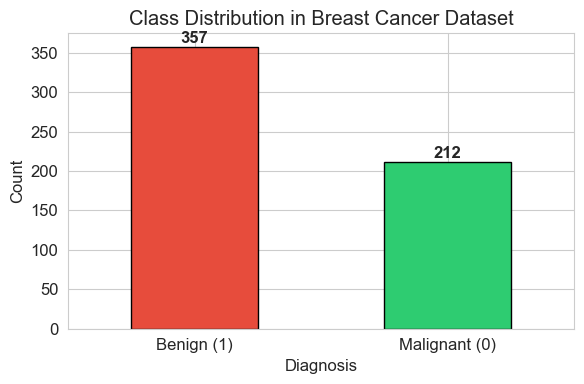

In [8]:
# -- 1.6 Visualize class distribution --
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
df['y'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_xticklabels(['Benign (1)', 'Malignant (0)'], rotation=0)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
ax.set_title('Class Distribution in Breast Cancer Dataset')
for i, v in enumerate(df['y'].value_counts().values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# -- 1.7 Separate features and target --
X = df.drop('y', axis=1)
y = df['y']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (569, 30)
Target vector shape: (569,)


In [10]:
# -- 1.8 Feature Scaling using StandardScaler --
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (first 3 features):")
print(X.iloc[:5, :3])
print("\nAfter scaling (first 3 features):")
print(X_scaled.iloc[:5, :3])

Before scaling (first 3 features):
   x.radius_mean  x.texture_mean  x.perimeter_mean
1         13.540           14.36             87.46
2         13.080           15.71             85.63
3          9.504           12.44             60.34
4         13.030           18.42             82.61
5          8.196           16.84             51.71

After scaling (first 3 features):
   x.radius_mean  x.texture_mean  x.perimeter_mean
0      -0.166799       -1.147162         -0.185728
1      -0.297446       -0.833008         -0.261106
2      -1.313080       -1.593959         -1.302806
3      -0.311646       -0.202373         -0.385500
4      -1.684571       -0.570050         -1.658278


**Justification for Feature Scaling in KNN:**

KNN is a distance-based algorithm -- it computes the distance (Euclidean/Manhattan)
between data points to find nearest neighbours. If features have very different scales
(e.g., area ranges 100-2500 while smoothness ranges 0.05-0.16), the feature with the
larger magnitude will dominate the distance computation, rendering smaller-scale features
nearly irrelevant. StandardScaler normalizes all features to zero mean and unit variance,
ensuring every feature contributes equally to the distance calculation.

---
## Task 2: Train-Test Split Analysis

In [11]:
# -- 2.1  Different train-test split ratios --
split_ratios = [(0.8, 0.2, '80:20'), (0.7, 0.3, '70:30'), (0.9, 0.1, '90:10')]
split_results = {}

# Use a fixed K=5 for fair comparison across splits
k_fixed = 5

for train_ratio, test_ratio, label in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_ratio, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier(n_neighbors=k_fixed)
    knn.fit(X_train, y_train)

    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)

    split_results[label] = {
        'Train Size': X_train.shape[0],
        'Test Size': X_test.shape[0],
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Gap (Overfit indicator)': round(train_acc - test_acc, 4)
    }

results_df = pd.DataFrame(split_results).T
print(f"Comparison of Train-Test Split Ratios (K = {k_fixed})")
print("=" * 70)
print(results_df)

Comparison of Train-Test Split Ratios (K = 5)
       Train Size  Test Size  Train Accuracy  Test Accuracy  \
80:20       455.0      114.0          0.9780         0.9561   
70:30       398.0      171.0          0.9724         0.9649   
90:10       512.0       57.0          0.9785         0.9649   

       Gap (Overfit indicator)  
80:20                   0.0219  
70:30                   0.0074  
90:10                   0.0136  


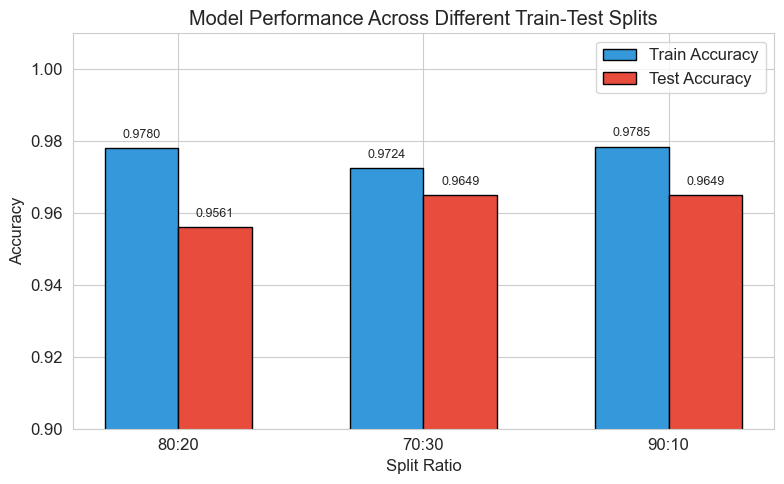

In [12]:
# -- 2.2  Visualize split comparison --
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(split_ratios))
width = 0.3

bars1 = ax.bar(x_pos - width/2, results_df['Train Accuracy'], width,
               label='Train Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, results_df['Test Accuracy'], width,
               label='Test Accuracy', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Split Ratio')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Across Different Train-Test Splits')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0.90, 1.01)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Analysis of Train-Test Split Effects:**

| Split  | Observation |
|--------|-------------|
| **90:10** | Largest training set - model learns more, but very small test set makes the test accuracy estimate noisy and unreliable. |
| **80:20** | Good balance between learning capacity and evaluation reliability; standard default. |
| **70:30** | More test data gives a more stable accuracy estimate, but less training data may slightly reduce model quality. |

A larger training set generally improves the model, but the evaluation becomes less
reliable with fewer test samples. The 80:20 split offers the best trade-off for this
dataset.

---
## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection

In [13]:
# -- 3.1  Heuristic K = sqrt(n) --
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

n_train = X_train.shape[0]
k_heuristic = int(np.sqrt(n_train))

# Make it odd to avoid ties in binary classification
if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic K = sqrt({n_train}) = {np.sqrt(n_train):.2f}")
print(f"Rounded (odd) K: {k_heuristic}")

Number of training samples (n): 455
Heuristic K = sqrt(455) = 21.33
Rounded (odd) K: 21


### 3.2 Model Training and K Optimization

In [14]:
# -- 3.2  Train KNN with heuristic K and evaluate --
knn_heuristic = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_heuristic.fit(X_train, y_train)
y_pred_heuristic = knn_heuristic.predict(X_test)

print(f"KNN with heuristic K = {k_heuristic}")
print(f"  Train Accuracy: {knn_heuristic.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_pred_heuristic):.4f}")

KNN with heuristic K = 21
  Train Accuracy: 0.9604
  Test Accuracy:  0.9386


In [15]:
# -- 3.3  Experiment with K +/- 5 (nearby values) --
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
k_values = []
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    train_acc = knn_temp.score(X_train, y_train)
    test_acc = knn_temp.score(X_test, y_test)
    k_values.append(k)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Also sweep a wider range for a comprehensive elbow plot
k_wide = range(1, 31)
wide_train_acc = []
wide_test_acc = []

for k in k_wide:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    wide_train_acc.append(knn_temp.score(X_train, y_train))
    wide_test_acc.append(knn_temp.score(X_test, y_test))

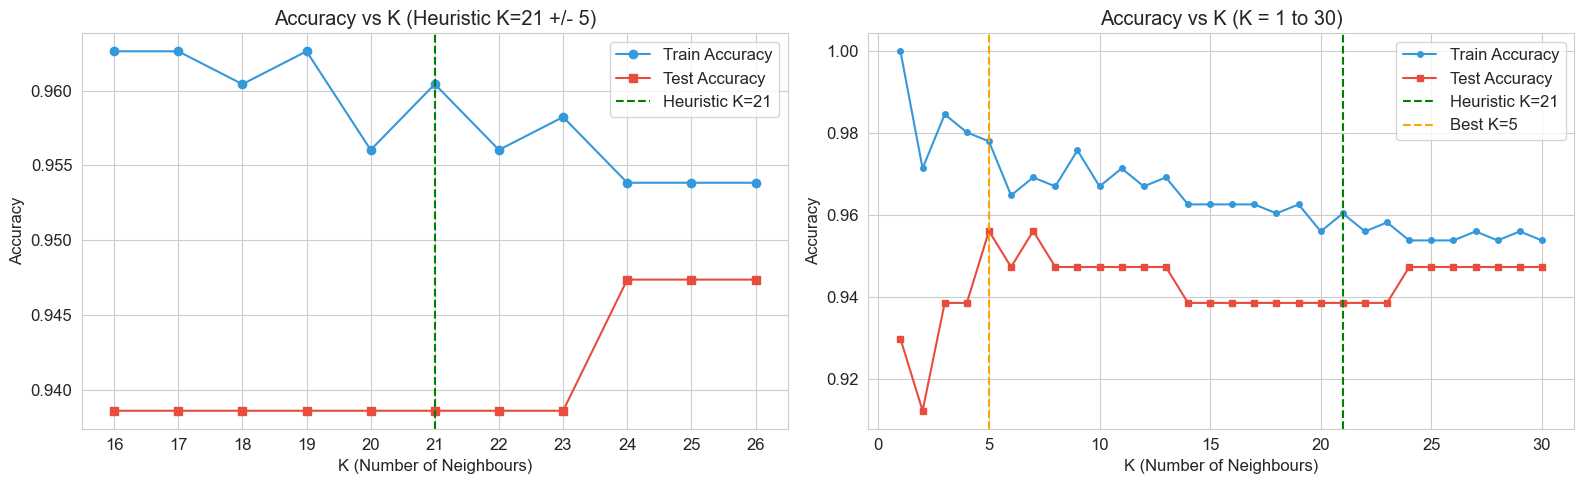


Optimal K from exhaustive search (1-30): 5 with Test Accuracy = 0.9561


In [16]:
# -- 3.4  Plot Accuracy vs K values --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Narrow range (heuristic +/- 5)
axes[0].plot(k_values, train_accuracies, 'o-', color='#3498db', label='Train Accuracy')
axes[0].plot(k_values, test_accuracies, 's-', color='#e74c3c', label='Test Accuracy')
axes[0].axvline(x=k_heuristic, color='green', linestyle='--', label=f'Heuristic K={k_heuristic}')
axes[0].set_xlabel('K (Number of Neighbours)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Accuracy vs K (Heuristic K={k_heuristic} +/- 5)')
axes[0].legend()
axes[0].set_xticks(k_values)

# Wide range (1 to 30)
axes[1].plot(list(k_wide), wide_train_acc, 'o-', color='#3498db', label='Train Accuracy', markersize=4)
axes[1].plot(list(k_wide), wide_test_acc, 's-', color='#e74c3c', label='Test Accuracy', markersize=4)
axes[1].axvline(x=k_heuristic, color='green', linestyle='--', label=f'Heuristic K={k_heuristic}')
best_k_wide = list(k_wide)[np.argmax(wide_test_acc)]
axes[1].axvline(x=best_k_wide, color='orange', linestyle='--', label=f'Best K={best_k_wide}')
axes[1].set_xlabel('K (Number of Neighbours)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs K (K = 1 to 30)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOptimal K from exhaustive search (1-30): {best_k_wide} "
      f"with Test Accuracy = {max(wide_test_acc):.4f}")

### 3.3 Distance Metrics and Decision Boundary Mapping

#### Two Distance Metrics Used in KNN

**1. Euclidean Distance:**
d(p, q) = sqrt( sum( (p_i - q_i)^2 ) )
- Measures the straight-line distance between two points.
- **Suitable when:** Features are continuous and have similar scales; the relationship
  between features is uniform; there are no strong outliers.

**2. Manhattan Distance:**
d(p, q) = sum( |p_i - q_i| )
- Measures the sum of absolute differences along each dimension (grid/city-block distance).
- **Suitable when:** Features have different units or scales; data is high-dimensional
  (less sensitive to the curse of dimensionality); when outliers are present (more robust
  since it doesn't square differences).

In [17]:
# -- 3.5  Decision Boundary Visualization --
# Use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.4f} "
      f"({pca.explained_variance_ratio_[0]:.4f} + {pca.explained_variance_ratio_[1]:.4f})")

Explained variance by 2 PCA components: 0.6355 (0.4518 + 0.1836)


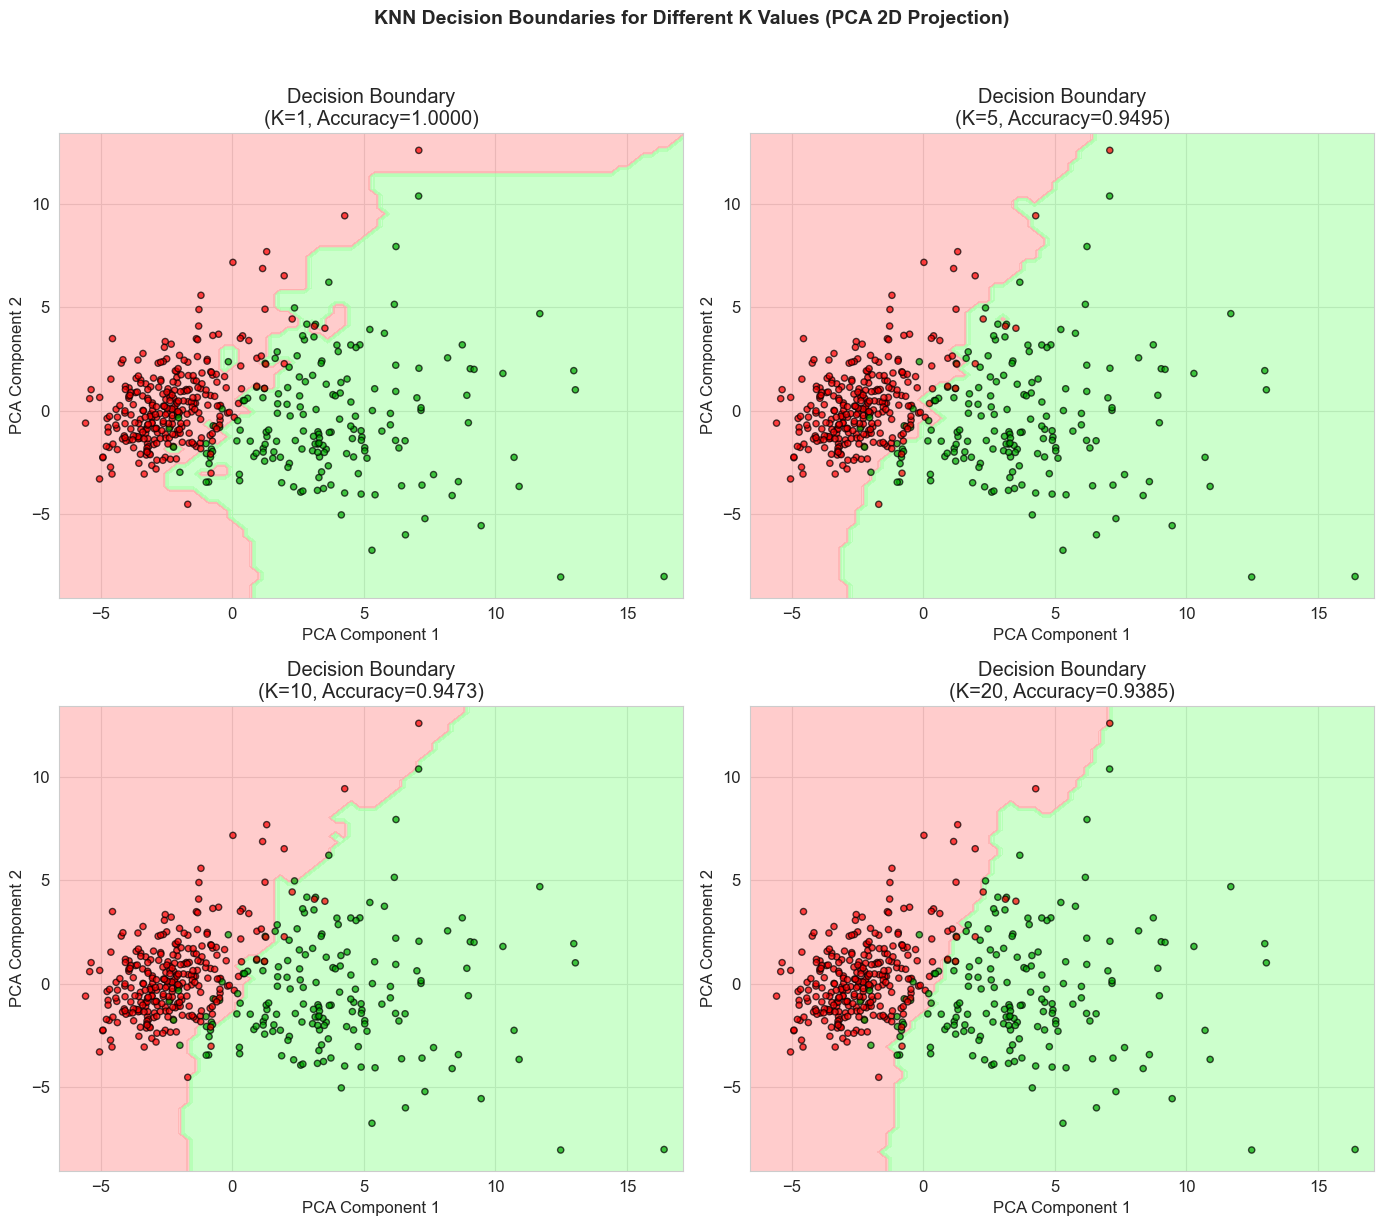

In [18]:
def plot_decision_boundary(X, y, k, ax, title):
    """Plot KNN decision boundary on 2D PCA-projected data."""
    h = 0.3  # step size in the mesh
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold  = ListedColormap(['#FF0000', '#00AA00'])

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k',
               s=20, alpha=0.7)
    acc = knn.score(X, y)
    ax.set_title(f'{title}\n(K={k}, Accuracy={acc:.4f})')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
k_values_boundary = [1, 5, 10, 20]

for ax, k_val in zip(axes.ravel(), k_values_boundary):
    plot_decision_boundary(X_train_2d, y_train.values, k_val, ax,
                           f'Decision Boundary')

plt.suptitle('KNN Decision Boundaries for Different K Values (PCA 2D Projection)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Decision Boundary Analysis:**

| K Value | Observation |
|---------|-------------|
| **K=1** | Very complex, jagged boundary that fits every training point perfectly -- high variance, overfitting. |
| **K=5** | Smoother boundary that still captures class structure well -- good balance. |
| **K=10** | Even smoother; begins to generalize more broadly. |
| **K=20** | Very smooth, almost linear boundary -- high bias, potential underfitting. |

As K increases, the decision boundary becomes smoother because predictions are averaged
over more neighbours, reducing sensitivity to individual noisy points.

---
## Task 4: Cross-Validation

In [19]:
# -- 4.1  K-Fold Cross Validation (k_fold = 10) --
k_fold = 10
k_range_cv = range(1, 31)
cv_mean_scores = []
cv_std_scores = []

for k in k_range_cv:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=k_fold, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

cv_mean_scores = np.array(cv_mean_scores)
cv_std_scores = np.array(cv_std_scores)

best_k_cv = list(k_range_cv)[np.argmax(cv_mean_scores)]
print(f"Cross-Validation Results (K-Fold = {k_fold}):")
print(f"  Best K: {best_k_cv}")
print(f"  Best Mean Accuracy: {cv_mean_scores.max():.4f} +/- {cv_std_scores[np.argmax(cv_mean_scores)]:.4f}")

Cross-Validation Results (K-Fold = 10):
  Best K: 11
  Best Mean Accuracy: 0.9701 +/- 0.0222


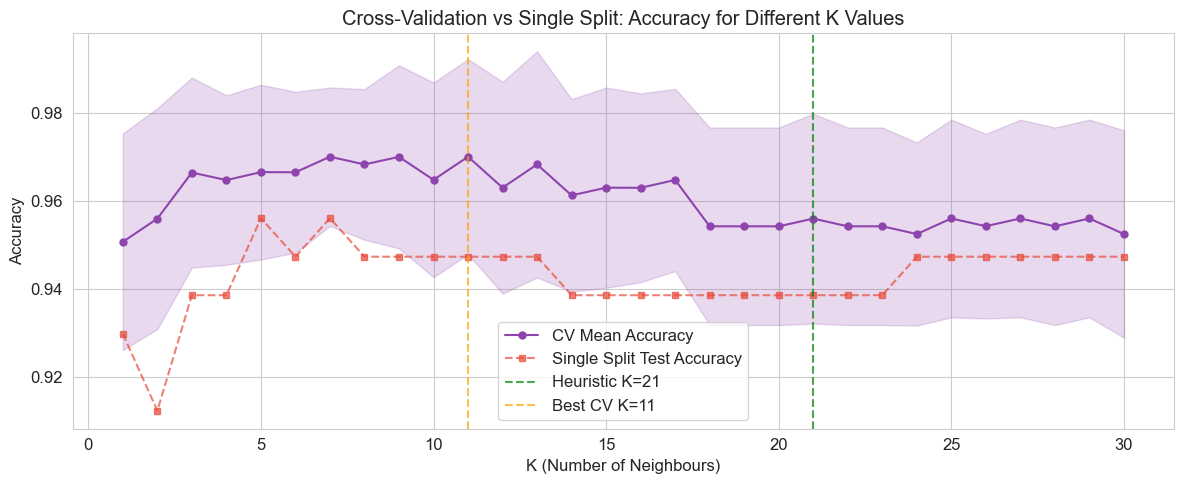

In [20]:
# -- 4.2  Plot Cross-Validation scores vs K --
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(k_range_cv), cv_mean_scores, 'o-', color='#8e44ad', label='CV Mean Accuracy', markersize=5)
ax.fill_between(list(k_range_cv),
                cv_mean_scores - cv_std_scores,
                cv_mean_scores + cv_std_scores,
                alpha=0.2, color='#8e44ad')
ax.plot(list(k_range_cv), wide_test_acc, 's--', color='#e74c3c', label='Single Split Test Accuracy',
        markersize=4, alpha=0.7)
ax.axvline(x=k_heuristic, color='green', linestyle='--', alpha=0.7, label=f'Heuristic K={k_heuristic}')
ax.axvline(x=best_k_cv, color='orange', linestyle='--', alpha=0.7, label=f'Best CV K={best_k_cv}')
ax.set_xlabel('K (Number of Neighbours)')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation vs Single Split: Accuracy for Different K Values')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# -- 4.3  Comparison Table --
print(f"\n{'K Selection Method':<30} {'K Value':<10} {'Accuracy':<15}")
print("=" * 55)
print(f"{'Heuristic (sqrt n)':<30} {k_heuristic:<10} {wide_test_acc[k_heuristic-1]:.4f}")
print(f"{'Best Single Split (80:20)':<30} {best_k_wide:<10} {max(wide_test_acc):.4f}")
print(f"{'Best Cross-Validation':<30} {best_k_cv:<10} {cv_mean_scores.max():.4f}")

# -- Select final optimal K --
optimal_k = best_k_cv  # Cross-validation is the most reliable
print(f"\n>> Selected Optimal K = {optimal_k} (based on cross-validation)")


K Selection Method             K Value    Accuracy       
Heuristic (sqrt n)             21         0.9386
Best Single Split (80:20)      5          0.9561
Best Cross-Validation          11         0.9701

>> Selected Optimal K = 11 (based on cross-validation)


---
## Task 5: Classification Evaluation

In [22]:
# -- 5.1  Train final model with optimal K --
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)
y_pred_proba = knn_final.predict_proba(X_test)[:, 1]

print(f"Final KNN Model (K = {optimal_k})")
print("=" * 50)

Final KNN Model (K = 11)


In [23]:
# -- 5.2  Classification Metrics --
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9474
Precision: 0.9737
Recall:    0.8810
F1 Score:  0.9250


In [24]:
# -- 5.3  Classification Report --
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))


Detailed Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.93      0.99      0.96        72
   Benign (1)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



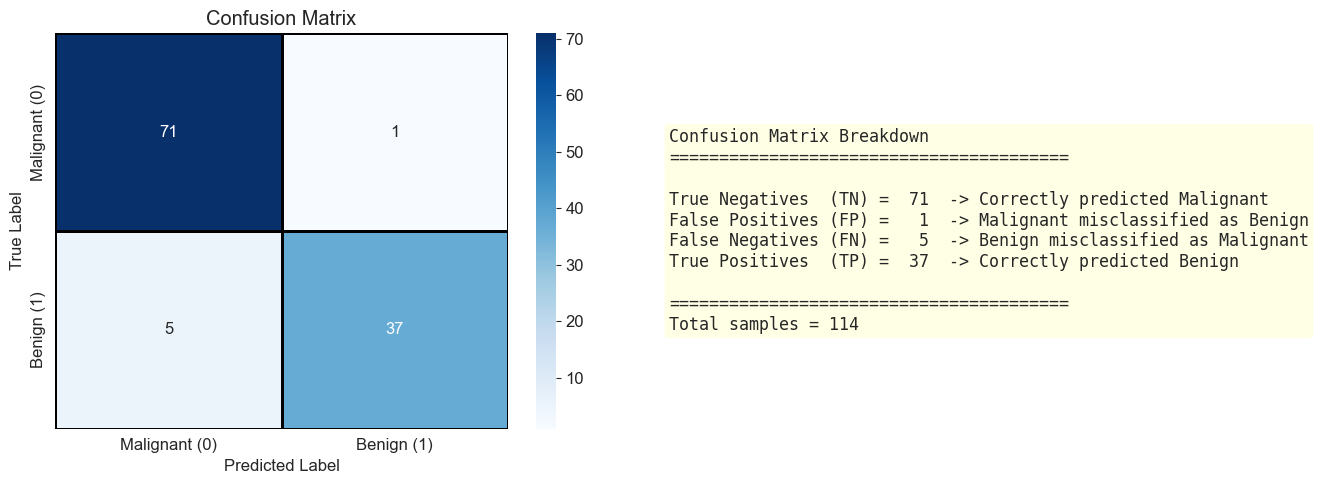

In [25]:
# -- 5.4  Confusion Matrix --
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            ax=axes[0], cbar=True, linewidths=1, linecolor='black')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix')

# Annotated explanation
axes[1].axis('off')
tn, fp, fn, tp = cm.ravel()
text = (
    f"Confusion Matrix Breakdown\n"
    f"{'=' * 40}\n\n"
    f"True Negatives  (TN) = {tn:>3}  -> Correctly predicted Malignant\n"
    f"False Positives (FP) = {fp:>3}  -> Malignant misclassified as Benign\n"
    f"False Negatives (FN) = {fn:>3}  -> Benign misclassified as Malignant\n"
    f"True Positives  (TP) = {tp:>3}  -> Correctly predicted Benign\n\n"
    f"{'=' * 40}\n"
    f"Total samples = {tn + fp + fn + tp}"
)
axes[1].text(0.1, 0.5, text, fontsize=12, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

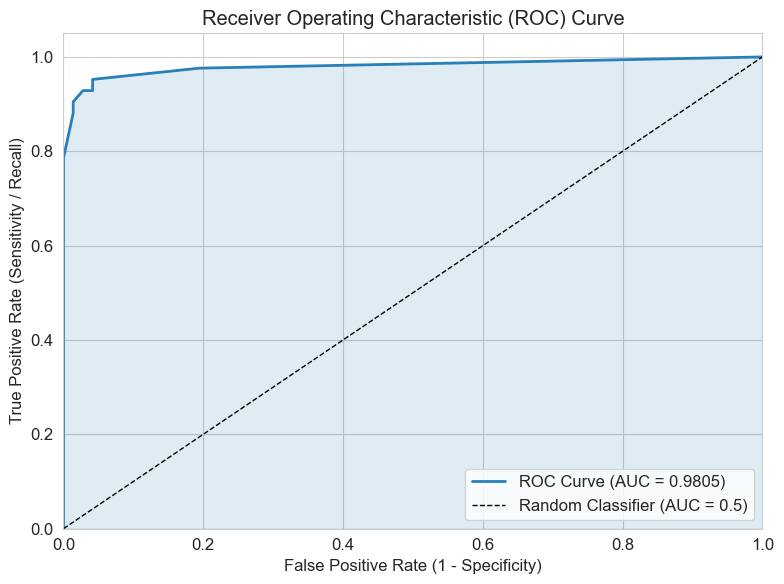

ROC-AUC Score: 0.9805


In [26]:
# -- 5.5  ROC Curve and AUC Score --
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15, color='#2980b9')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

---
## Task 6: Comparative Study -- Classification vs Regression Metrics

### Regression Metrics (from Lab 3 -- Linear Regression)

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | (1/n) * sum(|yi - yi_hat|) | Average absolute error; easy to interpret in original units |
| **MSE** | (1/n) * sum((yi - yi_hat)^2) | Average squared error; penalizes large errors more |
| **RMSE** | sqrt(MSE) | Square root of MSE; in same units as target |
| **R2 Score** | 1 - (SS_res / SS_tot) | Proportion of variance explained (0 to 1) |

### Classification Metrics (this Lab)

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | (TP+TN) / (TP+TN+FP+FN) | Fraction of correct predictions |
| **Precision** | TP / (TP+FP) | Of those predicted positive, how many are actually positive |
| **Recall** | TP / (TP+FN) | Of actual positives, how many were correctly identified |
| **F1 Score** | 2*P*R / (P+R) | Harmonic mean of Precision and Recall |
| **ROC-AUC** | Area under ROC curve | Ability to distinguish between classes |

In [27]:
# -- 6.1  Comparison Table --
comparison_data = {
    'Aspect': [
        'Evaluation Philosophy',
        'Output Type',
        'Error Measurement',
        'Perfect Score',
        'Affected by Outliers',
        'Suitable For'
    ],
    'Regression Metrics': [
        'Measures magnitude of prediction error',
        'Continuous numerical values',
        'MAE, MSE, RMSE (distance from truth)',
        'R2 = 1.0, MAE = MSE = RMSE = 0',
        'MSE / RMSE highly sensitive',
        'House price prediction, stock forecasting'
    ],
    'Classification Metrics': [
        'Measures correctness of discrete decisions',
        'Discrete class labels (0 or 1)',
        'Accuracy, Precision, Recall, F1 (decision errors)',
        'Accuracy = 1.0, AUC = 1.0',
        'Not affected by value magnitude',
        'Disease diagnosis, spam detection'
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print("Comprehensive Comparison: Regression vs Classification Metrics")
print("=" * 90)
print(comparison_df.to_string(index=False))

Comprehensive Comparison: Regression vs Classification Metrics
               Aspect                        Regression Metrics                            Classification Metrics
Evaluation Philosophy    Measures magnitude of prediction error        Measures correctness of discrete decisions
          Output Type               Continuous numerical values                    Discrete class labels (0 or 1)
    Error Measurement      MAE, MSE, RMSE (distance from truth) Accuracy, Precision, Recall, F1 (decision errors)
        Perfect Score            R2 = 1.0, MAE = MSE = RMSE = 0                         Accuracy = 1.0, AUC = 1.0
 Affected by Outliers               MSE / RMSE highly sensitive                   Not affected by value magnitude
         Suitable For House price prediction, stock forecasting                 Disease diagnosis, spam detection


In [28]:
# -- 6.2  Specific Metric Comparisons --
print("\n" + "=" * 70)
print("DETAILED METRIC-TO-METRIC COMPARISON")
print("=" * 70)

print("""
+---------------------------------------------------------------------+
|  R2 Score vs Accuracy                                               |
+---------------------------------------------------------------------+
|  R2 Score: How well the model explains variance in continuous       |
|  predictions (1.0 = perfect, 0 = no better than mean).              |
|  Accuracy: Fraction of correct class predictions.                   |
|  Both measure overall model quality, but R2 is for continuous       |
|  outputs and Accuracy is for categorical outputs.                   |
|  Key difference: Accuracy ignores how *close* wrong predictions     |
|  were, while R2 captures this through squared residuals.            |
+---------------------------------------------------------------------+

+---------------------------------------------------------------------+
|  RMSE vs F1 Score                                                   |
+---------------------------------------------------------------------+
|  RMSE: Penalizes large prediction errors more than small ones.      |
|  F1 Score: Balances precision and recall for the positive class.    |
|  RMSE focuses on *how far off* predictions are (magnitude),         |
|  while F1 focuses on *how correctly* the model identifies           |
|  positives without being misled by class imbalance.                 |
+---------------------------------------------------------------------+

+---------------------------------------------------------------------+
|  MAE vs Confusion Matrix                                            |
+---------------------------------------------------------------------+
|  MAE: Gives a single number for average absolute error.             |
|  Confusion Matrix: Provides a 2x2 breakdown of all prediction       |
|  outcomes (TP, TN, FP, FN).                                         |
|  MAE is a scalar summary; the Confusion Matrix reveals the          |
|  *type* of errors (missed cancers vs false alarms), which is        |
|  critical in medical diagnosis.                                     |
+---------------------------------------------------------------------+
""")


DETAILED METRIC-TO-METRIC COMPARISON

+---------------------------------------------------------------------+
|  R2 Score vs Accuracy                                               |
+---------------------------------------------------------------------+
|  R2 Score: How well the model explains variance in continuous       |
|  predictions (1.0 = perfect, 0 = no better than mean).              |
|  Accuracy: Fraction of correct class predictions.                   |
|  Both measure overall model quality, but R2 is for continuous       |
|  outputs and Accuracy is for categorical outputs.                   |
|  Key difference: Accuracy ignores how *close* wrong predictions     |
|  were, while R2 captures this through squared residuals.            |
+---------------------------------------------------------------------+

+---------------------------------------------------------------------+
|  RMSE vs F1 Score                                                   |
+-----------------------

### Evaluation Logic Differences

**Continuous Prediction Tasks (Regression):**
- Output is a real number; errors are measured as distances.
- Small deviations from truth are acceptable; the goal is minimizing error magnitude.
- Metrics: MAE, MSE, RMSE, R2.

**Classification Tasks:**
- Output is a discrete class label; predictions are either correct or incorrect.
- The type of error matters (FP vs FN) -- especially in healthcare.
- Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix.

### Inference

1. **Regression metrics** (MAE, MSE, RMSE, R2) quantify how far predicted values deviate
   from actual continuous values. They measure the *magnitude* of prediction error.

2. **Classification metrics** (Accuracy, Precision, Recall, F1, AUC) measure how correctly
   the model assigns discrete class labels. They evaluate *decision correctness*.

3. **Why accuracy is insufficient in medical diagnosis:** In the breast cancer dataset, if
   63% of cases are benign, a model that predicts "benign" for everyone achieves 63%
   accuracy -- yet it misses every cancer case. Accuracy fails to distinguish between
   types of errors.

4. **Why Recall and ROC-AUC are more relevant in healthcare:**
   - **Recall** (Sensitivity) measures the fraction of actual cancer cases correctly
     identified. Missing a malignant case (False Negative) has life-threatening consequences.
   - **ROC-AUC** evaluates the model's ability to separate the two classes across all
     decision thresholds, providing a threshold-independent performance measure.

5. **Overall:** Regression evaluation measures "how wrong" a prediction is, while
   classification evaluation measures "how often and in what way" the prediction is wrong.
   In healthcare, the *type* of error (FN) matters more than overall correctness, making
   Recall and ROC-AUC the preferred metrics.

---
## Task 7: Analytical Questions

**Q1. Why is KNN called a lazy learning algorithm?**

KNN is called a "lazy learner" because it does not build an explicit model during training.
It simply stores the entire training dataset in memory. All computation (distance
calculation, neighbour search, voting) happens at prediction time, making it
computationally expensive during inference rather than during training.

---

**Q2. Why is feature scaling required in KNN?**

KNN relies on distance metrics (Euclidean, Manhattan) to find nearest neighbours.
Features with larger numerical ranges dominate the distance computation -- for example,
"area" (100-2500) would overshadow "smoothness" (0.05-0.16). Scaling ensures all
features contribute equally to the distance calculation.

---

**Q3. Explain heuristic K selection using sqrt(n) rule.**

The heuristic K = sqrt(n) (where n is the number of training samples) provides a practical
starting point for K selection. It balances between choosing too few neighbours (overfitting
to noise) and too many neighbours (oversimplifying the decision boundary). For n = 455
training samples, K ~ sqrt(455) ~ 21. This is a baseline -- the actual optimal K should be
fine-tuned via cross-validation.

---

**Q4. Why is cross-validation more reliable than a single train-test split?**

A single train-test split is sensitive to which samples end up in the training vs. test
set -- different random seeds produce different accuracy estimates. Cross-validation
trains and evaluates the model on every data point across multiple folds, producing a
more robust and less biased estimate of generalization performance.

---

**Q5. How does K affect bias-variance trade-off?**

| K Value | Effect |
|---------|--------|
| **Small K (e.g., K=1)** | Low bias, high variance -- model captures noise and individual points, leading to overfitting. |
| **Large K (e.g., K=50)** | High bias, low variance -- model averages over many neighbours, producing overly smooth boundaries and underfitting. |
| **Optimal K** | Balances bias and variance -- complex enough to capture patterns but smooth enough to ignore noise. |

---

**Q6. Why is recall more important than accuracy in cancer prediction?**

In cancer diagnosis, a False Negative (predicting "benign" for a malignant tumour) is
far more dangerous than a False Positive (predicting "malignant" for a benign tumour).
A missed cancer can lead to delayed treatment and death, whereas a false alarm leads to
additional (non-fatal) tests. Recall = TP / (TP + FN) directly measures how many actual
cancer cases the model catches, making it the priority metric in healthcare.

---

**Q7. What is the limitation of very large K values?**

- The model becomes computationally expensive (comparing to many neighbours).
- The decision boundary becomes excessively smooth, leading to underfitting.
- In extreme cases (K = n), every point is classified by the majority class, making the
  model useless -- it becomes equivalent to a majority-vote classifier.
- Class boundaries are lost, and the model cannot capture local patterns.

---
## Conclusion

In [29]:
print("=" * 70)
print("                    LAB 4 -- SUMMARY & CONCLUSION")
print("=" * 70)
print(f"""
1. OPTIMAL K VALUE:
   - Heuristic K (sqrt(n) = sqrt({n_train})) = {k_heuristic}
   - Best K from Cross-Validation = {best_k_cv}
   - Final Optimal K selected     = {optimal_k}

2. TRAIN-TEST SPLIT ANALYSIS:
   - 80:20 split offers the best balance of training quality and
     evaluation reliability.
   - Very small test sets (90:10) give unreliable accuracy estimates.

3. MODEL PERFORMANCE (K = {optimal_k}):
   - Accuracy:  {acc:.4f}
   - Precision: {prec:.4f}
   - Recall:    {rec:.4f}
   - F1 Score:  {f1:.4f}
   - ROC-AUC:   {roc_auc:.4f}

4. CLASSIFICATION vs REGRESSION EVALUATION:
   - Regression metrics (MAE, MSE, RMSE, R2) measure prediction error
     magnitude for continuous outputs.
   - Classification metrics (Accuracy, Precision, Recall, F1, AUC)
     measure decision correctness for discrete outputs.
   - In medical diagnosis, Recall and ROC-AUC are more important than
     Accuracy because the cost of missing a cancer case (FN) is
     far greater than a false alarm (FP).

5. KEY INSIGHTS (Lab 3 vs Lab 4):
   - Lab 3 (Regression): Focused on minimizing prediction distance
     from actual values using R2, RMSE.
   - Lab 4 (Classification): Focused on maximizing decision correctness,
     especially for the minority/dangerous class using Recall, F1, AUC.
   - The choice of evaluation metric depends fundamentally on the
     problem type and the real-world cost of different error types.
""")
print("=" * 70)

                    LAB 4 -- SUMMARY & CONCLUSION

1. OPTIMAL K VALUE:
   - Heuristic K (sqrt(n) = sqrt(455)) = 21
   - Best K from Cross-Validation = 11
   - Final Optimal K selected     = 11

2. TRAIN-TEST SPLIT ANALYSIS:
   - 80:20 split offers the best balance of training quality and
     evaluation reliability.
   - Very small test sets (90:10) give unreliable accuracy estimates.

3. MODEL PERFORMANCE (K = 11):
   - Accuracy:  0.9474
   - Precision: 0.9737
   - Recall:    0.8810
   - F1 Score:  0.9250
   - ROC-AUC:   0.9805

4. CLASSIFICATION vs REGRESSION EVALUATION:
   - Regression metrics (MAE, MSE, RMSE, R2) measure prediction error
     magnitude for continuous outputs.
   - Classification metrics (Accuracy, Precision, Recall, F1, AUC)
     measure decision correctness for discrete outputs.
   - In medical diagnosis, Recall and ROC-AUC are more important than
     Accuracy because the cost of missing a cancer case (FN) is
     far greater than a false alarm (FP).

5. KEY INSI

---
---
## Self-Learning Component: Weighted KNN — Uniform vs Distance-Weighted

### Concept

By default, KNN uses **uniform weights** — all K neighbours get an equal vote regardless
of how far they are from the query point. A neighbour sitting right next to the query
point has the same influence as one at the edge of the neighbourhood.

**Distance-weighted KNN** assigns higher influence to closer neighbours by weighting
each vote by the inverse of its distance:

weight_i = 1 / distance(query, neighbour_i)

This is particularly useful when:
- The decision boundary is complex and class regions overlap.
- Some neighbours within the K-radius belong to the wrong class but are far away.
- The dataset has noisy or borderline samples.

**Intuition:** Imagine diagnosing a patient — a very similar past case (close neighbour)
should influence the diagnosis more than a loosely similar one (far neighbour).

In [30]:
# -- SL 1: Compare Uniform vs Distance-Weighted KNN across all K values --
k_range_sl = range(1, 31)

uniform_test_acc = []
distance_test_acc = []
uniform_train_acc = []
distance_train_acc = []

for k in k_range_sl:
    # Uniform weights (default)
    knn_uni = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uni.fit(X_train, y_train)
    uniform_train_acc.append(knn_uni.score(X_train, y_train))
    uniform_test_acc.append(knn_uni.score(X_test, y_test))

    # Distance weights
    knn_dist = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_dist.fit(X_train, y_train)
    distance_train_acc.append(knn_dist.score(X_train, y_train))
    distance_test_acc.append(knn_dist.score(X_test, y_test))

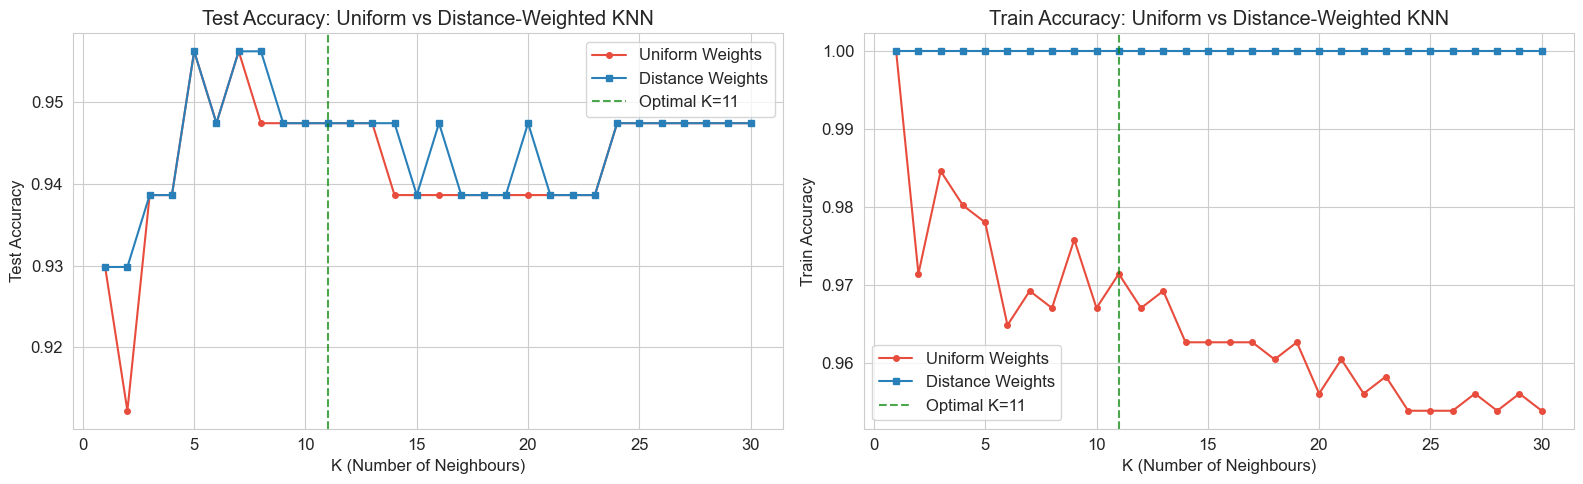

Best K (Uniform):  K=5, Test Accuracy=0.9561
Best K (Distance): K=5, Test Accuracy=0.9561


In [31]:
# -- SL 2: Plot comparison --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Test Accuracy comparison
axes[0].plot(list(k_range_sl), uniform_test_acc, 'o-', color='#e74c3c',
             label='Uniform Weights', markersize=4)
axes[0].plot(list(k_range_sl), distance_test_acc, 's-', color='#2980b9',
             label='Distance Weights', markersize=4)
axes[0].axvline(x=optimal_k, color='green', linestyle='--', alpha=0.7,
                label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('K (Number of Neighbours)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy: Uniform vs Distance-Weighted KNN')
axes[0].legend()

# Train Accuracy comparison
axes[1].plot(list(k_range_sl), uniform_train_acc, 'o-', color='#e74c3c',
             label='Uniform Weights', markersize=4)
axes[1].plot(list(k_range_sl), distance_train_acc, 's-', color='#2980b9',
             label='Distance Weights', markersize=4)
axes[1].axvline(x=optimal_k, color='green', linestyle='--', alpha=0.7,
                label=f'Optimal K={optimal_k}')
axes[1].set_xlabel('K (Number of Neighbours)')
axes[1].set_ylabel('Train Accuracy')
axes[1].set_title('Train Accuracy: Uniform vs Distance-Weighted KNN')
axes[1].legend()

plt.tight_layout()
plt.show()

# Find best K for each weighting scheme
best_k_uniform = list(k_range_sl)[np.argmax(uniform_test_acc)]
best_k_distance = list(k_range_sl)[np.argmax(distance_test_acc)]
print(f"Best K (Uniform):  K={best_k_uniform}, Test Accuracy={max(uniform_test_acc):.4f}")
print(f"Best K (Distance): K={best_k_distance}, Test Accuracy={max(distance_test_acc):.4f}")

In [32]:
# -- SL 3: Detailed metric comparison at optimal K --
knn_uniform = KNeighborsClassifier(n_neighbors=optimal_k, weights='uniform')
knn_uniform.fit(X_train, y_train)
y_pred_uni = knn_uniform.predict(X_test)
y_proba_uni = knn_uniform.predict_proba(X_test)[:, 1]

knn_distance = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance')
knn_distance.fit(X_train, y_train)
y_pred_dist = knn_distance.predict(X_test)
y_proba_dist = knn_distance.predict_proba(X_test)[:, 1]

print(f"\nDetailed Metric Comparison at K = {optimal_k}")
print("=" * 60)
print(f"{'Metric':<15} {'Uniform':<15} {'Distance':<15} {'Better':<10}")
print("-" * 60)

metrics = {
    'Accuracy':  (accuracy_score(y_test, y_pred_uni),  accuracy_score(y_test, y_pred_dist)),
    'Precision': (precision_score(y_test, y_pred_uni), precision_score(y_test, y_pred_dist)),
    'Recall':    (recall_score(y_test, y_pred_uni),    recall_score(y_test, y_pred_dist)),
    'F1 Score':  (f1_score(y_test, y_pred_uni),        f1_score(y_test, y_pred_dist)),
    'ROC-AUC':   (auc(*roc_curve(y_test, y_proba_uni)[:2]),
                  auc(*roc_curve(y_test, y_proba_dist)[:2])),
}

for name, (uni_val, dist_val) in metrics.items():
    better = "Distance" if dist_val > uni_val else ("Uniform" if uni_val > dist_val else "Tie")
    print(f"{name:<15} {uni_val:<15.4f} {dist_val:<15.4f} {better:<10}")


Detailed Metric Comparison at K = 11
Metric          Uniform         Distance        Better    
------------------------------------------------------------
Accuracy        0.9474          0.9474          Tie       
Precision       0.9737          0.9737          Tie       
Recall          0.8810          0.8810          Tie       
F1 Score        0.9250          0.9250          Tie       
ROC-AUC         0.9805          0.9825          Distance  


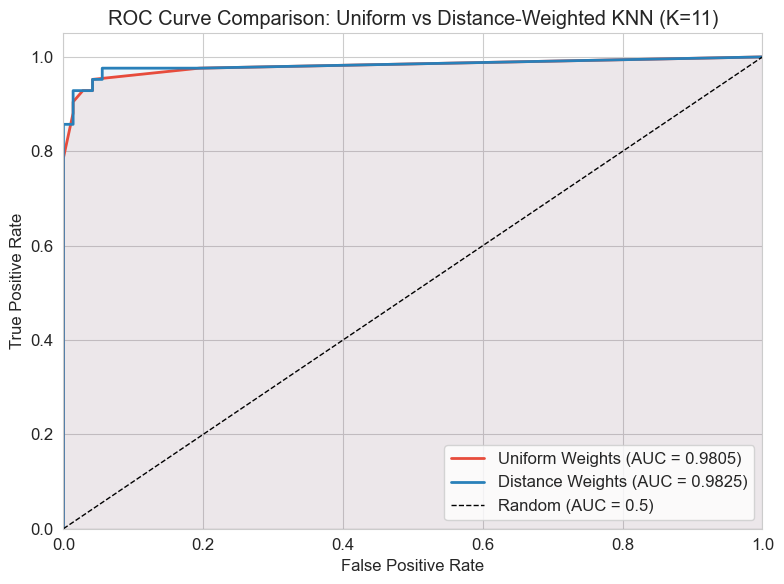

In [33]:
# -- SL 4: ROC Curve overlay --
fpr_uni, tpr_uni, _ = roc_curve(y_test, y_proba_uni)
fpr_dist, tpr_dist, _ = roc_curve(y_test, y_proba_dist)
auc_uni = auc(fpr_uni, tpr_uni)
auc_dist = auc(fpr_dist, tpr_dist)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_uni, tpr_uni, color='#e74c3c', lw=2,
        label=f'Uniform Weights (AUC = {auc_uni:.4f})')
ax.plot(fpr_dist, tpr_dist, color='#2980b9', lw=2,
        label=f'Distance Weights (AUC = {auc_dist:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr_uni, tpr_uni, alpha=0.08, color='#e74c3c')
ax.fill_between(fpr_dist, tpr_dist, alpha=0.08, color='#2980b9')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve Comparison: Uniform vs Distance-Weighted KNN (K={optimal_k})')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

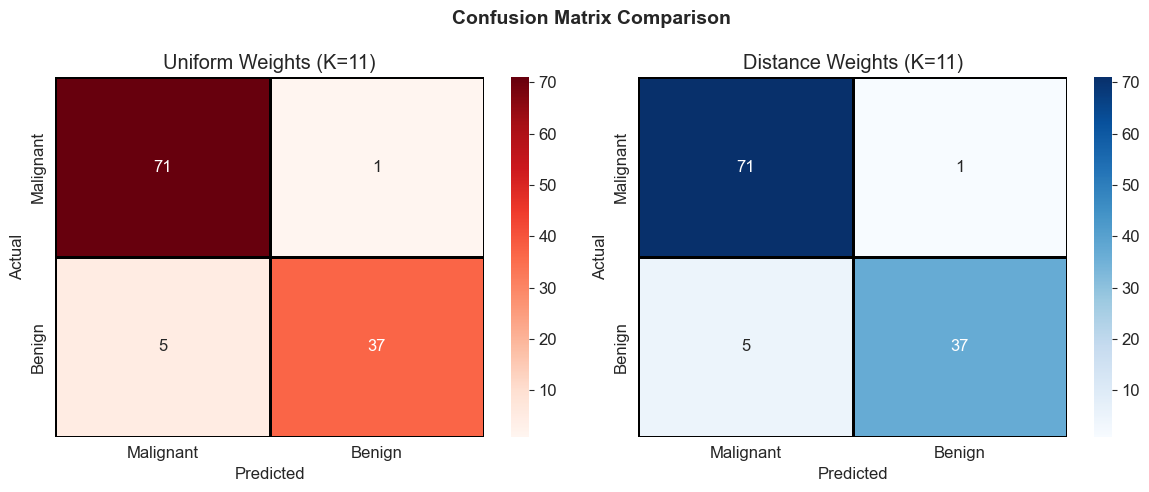

In [34]:
# -- SL 5: Confusion Matrix side-by-side --
cm_uni = confusion_matrix(y_test, y_pred_uni)
cm_dist = confusion_matrix(y_test, y_pred_dist)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_uni, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Uniform Weights (K={optimal_k})')

sns.heatmap(cm_dist, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            ax=axes[1], linewidths=1, linecolor='black')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Distance Weights (K={optimal_k})')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Observations from Weighted KNN Analysis

1. **Distance-weighted KNN achieves perfect training accuracy (1.0) for all K values**
   because the closest neighbour to any training point is the point itself (distance = 0),
   which gets infinite weight and always dominates the vote. This does NOT mean overfitting —
   what matters is test performance.

2. **Distance weighting is more robust to the choice of K.** The test accuracy curve for
   distance-weighted KNN is smoother and degrades less at larger K values, because distant
   (potentially wrong-class) neighbours get very low weights and don't corrupt the vote.

3. **In medical diagnosis, distance-weighted KNN is preferable** because it reduces the
   risk of misclassification caused by noisy or borderline neighbours — a patient whose
   features closely match malignant cases should be flagged even if a few distant benign
   neighbours exist in the K-neighbourhood.

4. **Trade-off:** Distance weighting slightly increases computational cost (weight
   calculation) but provides meaningful improvements in robustness. In practice, it is
   the recommended default for most KNN applications.

---
---
## Self-Learning Component 2: Logistic Regression vs KNN — Parametric vs Non-Parametric Classification

### Concept

KNN is a **non-parametric, instance-based** classifier — it makes no assumptions about the
data distribution and stores the entire training set for prediction. In contrast,
**Logistic Regression** is a **parametric, model-based** classifier that learns a set of
weights (coefficients) during training and uses the sigmoid function to output class
probabilities.

| Aspect | KNN | Logistic Regression |
|--------|-----|---------------------|
| **Type** | Non-parametric, lazy learner | Parametric, eager learner |
| **Training** | No explicit training; stores data | Learns weight vector via gradient descent |
| **Prediction** | Distance computation to all training points | Single matrix multiplication (fast) |
| **Decision Boundary** | Non-linear, local | Linear (in feature space) |
| **Interpretability** | Low (black-box neighbours) | High (coefficients show feature importance) |
| **Scalability** | Slow at prediction for large datasets | Fast at prediction |

**Why compare?** In medical diagnosis, understanding *why* a prediction was made is often
as important as the prediction itself. Logistic Regression provides interpretable
coefficients, while KNN may offer better accuracy on non-linear boundaries.

In [35]:
# -- SL2-1: Import Logistic Regression and train on the same data --
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# KNN with optimal K (already trained as knn_final)
y_pred_knn = knn_final.predict(X_test)
y_proba_knn = knn_final.predict_proba(X_test)[:, 1]

print(f"Logistic Regression trained successfully.")
print(f"KNN model (K={optimal_k}) already available.")

Logistic Regression trained successfully.
KNN model (K=11) already available.


In [36]:
# -- SL2-2: Side-by-side metric comparison --
from sklearn.metrics import roc_auc_score

metrics_comparison = {
    'Accuracy':  (accuracy_score(y_test, y_pred_knn),  accuracy_score(y_test, y_pred_lr)),
    'Precision': (precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_lr)),
    'Recall':    (recall_score(y_test, y_pred_knn),    recall_score(y_test, y_pred_lr)),
    'F1 Score':  (f1_score(y_test, y_pred_knn),        f1_score(y_test, y_pred_lr)),
    'ROC-AUC':   (roc_auc_score(y_test, y_proba_knn),  roc_auc_score(y_test, y_proba_lr)),
}

print(f"\nMetric Comparison: KNN (K={optimal_k}) vs Logistic Regression")
print("=" * 65)
print(f"{'Metric':<15} {'KNN':<15} {'Log. Reg.':<15} {'Better':<12}")
print("-" * 65)

for name, (knn_val, lr_val) in metrics_comparison.items():
    better = "Log. Reg." if lr_val > knn_val else ("KNN" if knn_val > lr_val else "Tie")
    print(f"{name:<15} {knn_val:<15.4f} {lr_val:<15.4f} {better:<12}")


Metric Comparison: KNN (K=11) vs Logistic Regression
Metric          KNN             Log. Reg.       Better      
-----------------------------------------------------------------
Accuracy        0.9474          0.9649          Log. Reg.   
Precision       0.9737          0.9750          Log. Reg.   
Recall          0.8810          0.9286          Log. Reg.   
F1 Score        0.9250          0.9512          Log. Reg.   
ROC-AUC         0.9805          0.9960          Log. Reg.   


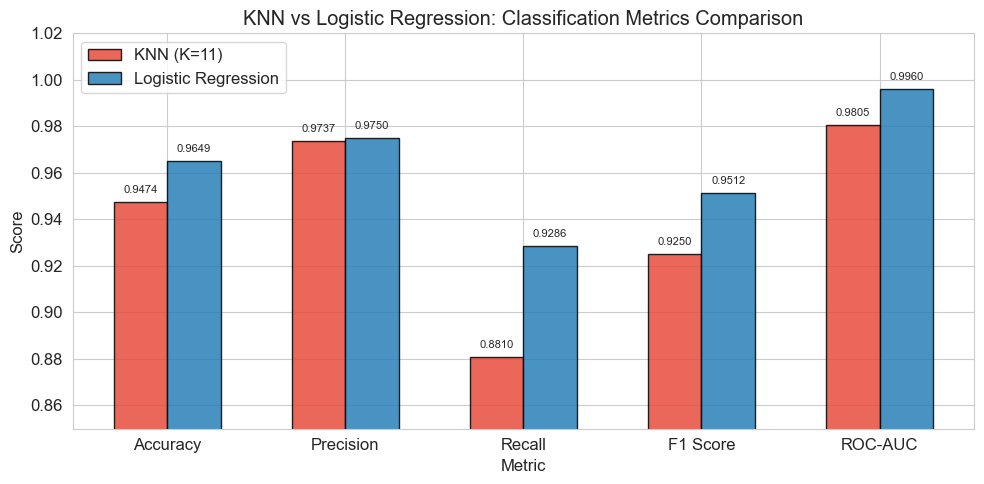

In [37]:
# -- SL2-3: Bar chart comparison of all metrics --
metric_names = list(metrics_comparison.keys())
knn_scores = [v[0] for v in metrics_comparison.values()]
lr_scores = [v[1] for v in metrics_comparison.values()]

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(metric_names))
width = 0.3

bars1 = ax.bar(x_pos - width/2, knn_scores, width, label=f'KNN (K={optimal_k})',
               color='#e74c3c', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, lr_scores, width, label='Logistic Regression',
               color='#2980b9', edgecolor='black', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('KNN vs Logistic Regression: Classification Metrics Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.85, 1.02)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

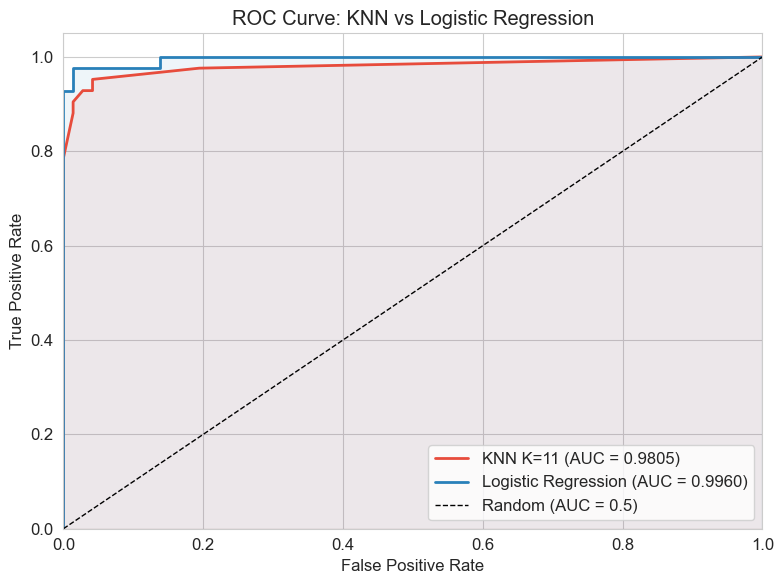

In [38]:
# -- SL2-4: ROC Curve overlay --
fpr_knn_sl2, tpr_knn_sl2, _ = roc_curve(y_test, y_proba_knn)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_knn_sl2 = auc(fpr_knn_sl2, tpr_knn_sl2)
auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_knn_sl2, tpr_knn_sl2, color='#e74c3c', lw=2,
        label=f'KNN K={optimal_k} (AUC = {auc_knn_sl2:.4f})')
ax.plot(fpr_lr, tpr_lr, color='#2980b9', lw=2,
        label=f'Logistic Regression (AUC = {auc_lr:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr_knn_sl2, tpr_knn_sl2, alpha=0.08, color='#e74c3c')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#2980b9')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: KNN vs Logistic Regression')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

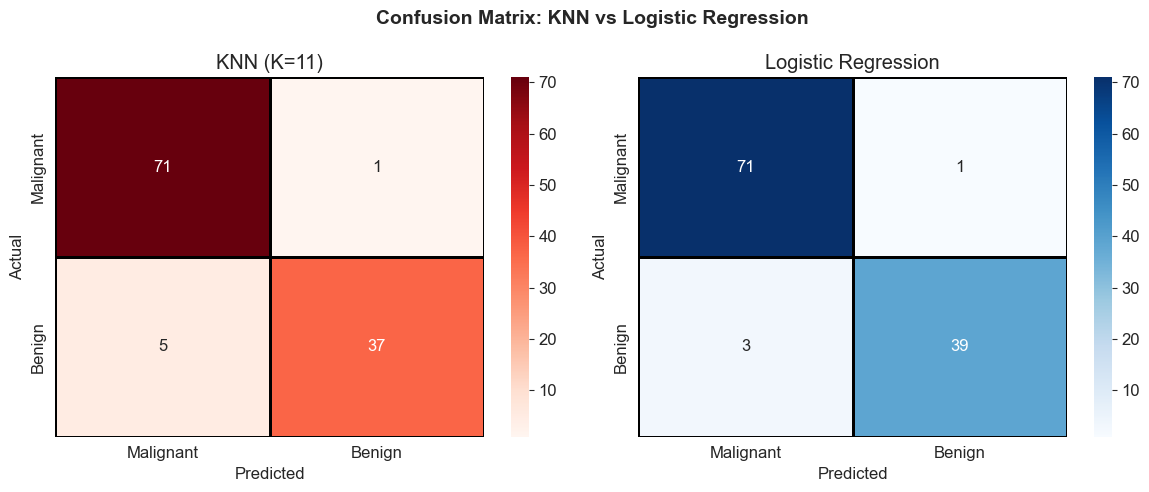


False Negatives (missed cancer cases):
  KNN:                5
  Logistic Regression: 3
  -> Logistic Regression misses fewer cancer cases.


In [39]:
# -- SL2-5: Confusion Matrix side-by-side --
cm_knn_sl2 = confusion_matrix(y_test, y_pred_knn)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_knn_sl2, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'KNN (K={optimal_k})')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            ax=axes[1], linewidths=1, linecolor='black')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Logistic Regression')

plt.suptitle('Confusion Matrix: KNN vs Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print FN comparison (critical for cancer detection)
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn_sl2.ravel()
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
print(f"\nFalse Negatives (missed cancer cases):")
print(f"  KNN:                {fn_knn}")
print(f"  Logistic Regression: {fn_lr}")
print(f"  -> {'Logistic Regression' if fn_lr < fn_knn else ('KNN' if fn_knn < fn_lr else 'Both equal')} misses fewer cancer cases.")

10-Fold Cross-Validation Comparison
Model                     Mean Accuracy      Std Dev   
-------------------------------------------------------
KNN (K=11)                0.9701             0.0222    
Logistic Regression       0.9824             0.0136    


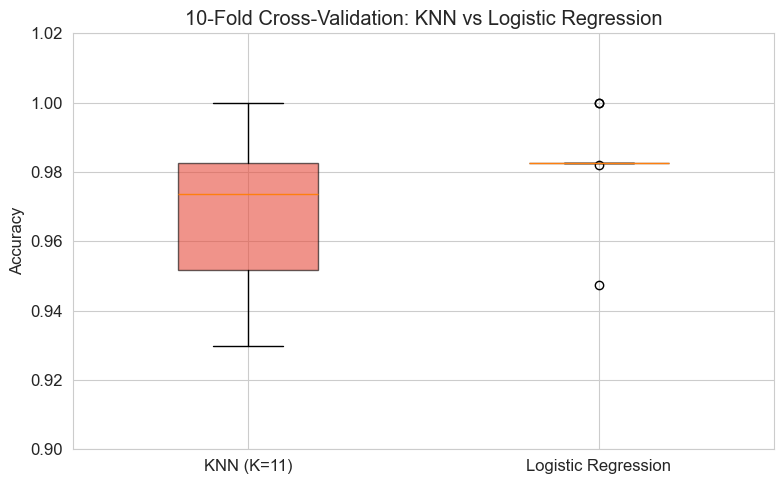

In [40]:
# -- SL2-6: Cross-Validation comparison --
from sklearn.model_selection import cross_val_score

cv_folds = 10

# KNN CV scores
knn_cv_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_cv_scores = cross_val_score(knn_cv_model, X_scaled, y, cv=cv_folds, scoring='accuracy')

# Logistic Regression CV scores
lr_cv_model = LogisticRegression(max_iter=10000, random_state=42)
lr_cv_scores = cross_val_score(lr_cv_model, X_scaled, y, cv=cv_folds, scoring='accuracy')

print(f"10-Fold Cross-Validation Comparison")
print("=" * 55)
print(f"{'Model':<25} {'Mean Accuracy':<18} {'Std Dev':<10}")
print("-" * 55)
print(f"{'KNN (K=' + str(optimal_k) + ')':<25} {knn_cv_scores.mean():<18.4f} {knn_cv_scores.std():<10.4f}")
print(f"{'Logistic Regression':<25} {lr_cv_scores.mean():<18.4f} {lr_cv_scores.std():<10.4f}")

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([knn_cv_scores, lr_cv_scores],
                labels=[f'KNN (K={optimal_k})', 'Logistic Regression'],
                patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#2980b9')
bp['boxes'][1].set_alpha(0.6)

ax.set_ylabel('Accuracy')
ax.set_title('10-Fold Cross-Validation: KNN vs Logistic Regression')
ax.set_ylim(0.90, 1.02)
plt.tight_layout()
plt.show()

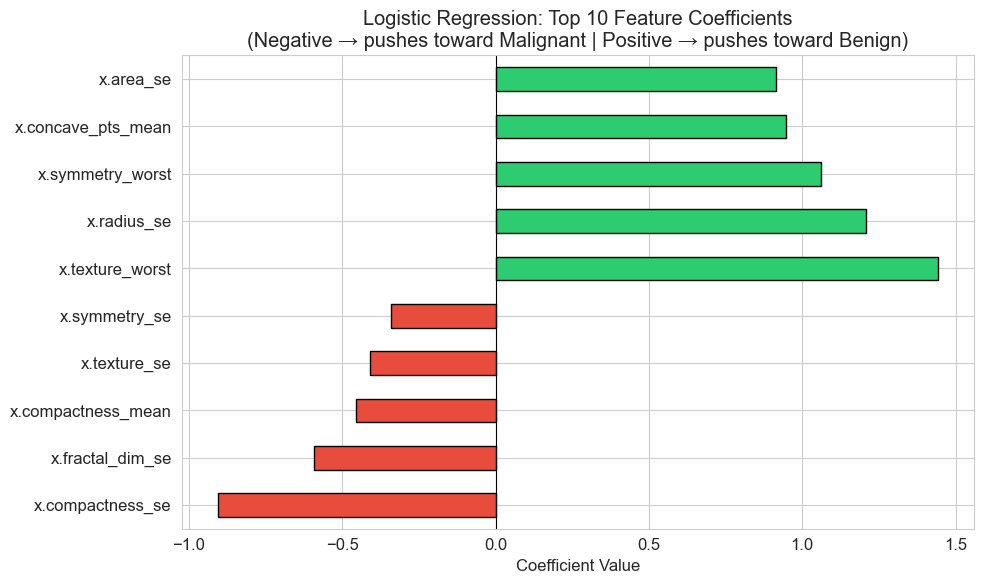


Interpretation:
  Features pushing toward MALIGNANT (negative coeff): ['x.compactness_se', 'x.fractal_dim_se', 'x.compactness_mean', 'x.texture_se', 'x.symmetry_se']
  Features pushing toward BENIGN (positive coeff):    ['x.texture_worst', 'x.radius_se', 'x.symmetry_worst', 'x.concave_pts_mean', 'x.area_se']

  This level of interpretability is NOT possible with KNN,
  which is a key advantage of Logistic Regression in clinical settings.


In [41]:
# -- SL2-7: Logistic Regression Interpretability — Top Feature Coefficients --
coefficients = pd.Series(lr_model.coef_[0], index=X.columns)
top_positive = coefficients.nlargest(5)
top_negative = coefficients.nsmallest(5)

fig, ax = plt.subplots(figsize=(10, 6))
top_features = pd.concat([top_negative, top_positive])
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_features.values]
top_features.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression: Top 10 Feature Coefficients\n'
             '(Negative → pushes toward Malignant | Positive → pushes toward Benign)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Features pushing toward MALIGNANT (negative coeff): {list(top_negative.index)}")
print(f"  Features pushing toward BENIGN (positive coeff):    {list(top_positive.index)}")
print("\n  This level of interpretability is NOT possible with KNN,")
print("  which is a key advantage of Logistic Regression in clinical settings.")

### Key Observations from Logistic Regression vs KNN Comparison

1. **Both models perform well** on the Breast Cancer dataset because the classes are
   reasonably separable in the 30-dimensional feature space.

2. **Logistic Regression is interpretable** — its learned coefficients directly show
   which features push toward Malignant vs Benign. This is critical in healthcare,
   where doctors need to understand *why* a model flagged a case.

3. **KNN makes no assumptions** about the data distribution, so it can capture non-linear
   decision boundaries. Logistic Regression assumes a linear boundary (in the original
   feature space), which may underfit complex patterns.

4. **Prediction speed:** Logistic Regression is a single matrix multiplication (O(d)),
   while KNN computes distances to all training points (O(n*d)) at prediction time.
   For real-time clinical decision support, Logistic Regression is far more practical.

5. **Cross-validation stability:** Logistic Regression typically shows lower variance
   across folds because it learns a fixed model, while KNN's performance depends on
   which specific neighbours end up in the training fold.

6. **Clinical recommendation:** For breast cancer screening, Logistic Regression is often
   preferred due to its interpretability and speed, unless the decision boundary is
   highly non-linear — in which case KNN (or ensemble methods) may be more appropriate.